In [35]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score,roc_curve,recall_score,precision_score

import matplotlib.pyplot as plt

In [28]:
def build_preprocessor(df):
    
    # target
    target = "Churn"
    
    # separate features
    X = df.drop(columns=[target])
    
    # identify columns
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = X.select_dtypes(exclude="object").columns.tolist()
    
    # remove ID if present
    if "customerID" in X.columns:
        cat_cols.remove("customerID")
        X = X.drop(columns=["customerID"])
    
    # transformers
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )
    
    return preprocessor, X

In [29]:
df = pd.read_csv("../data/churn.csv")
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

#Some feature engineering

df["tenure_group"] = pd.cut(df["tenure"], bins=[0,12,24,48,72]).astype(str)

services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df["num_services"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

df["high_charges"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

df["contract_length"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

preprocessor, X = build_preprocessor(df)
y = df["Churn"]

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

scores = cross_val_score(
    logistic_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.8467166584336813


In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = [
        {
            "clf__penalty": ["l2"],
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__solver": ["lbfgs"]
        },
        {
            "clf__penalty": ["l1"],
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__solver": ["liblinear"]
        }
]

grid = GridSearchCV(
    logistic_pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


In [33]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)
y_val_prob = best_model.predict_proba(X_val)[:, 1]

In [36]:
thresholds = np.linspace(0.1, 0.9, 81)

best_threshold = 0.5
best_precision = 0

for t in thresholds:
    y_val_pred = (y_val_prob >= t).astype(int)
    
    recall = recall_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    
    if recall >= 0.8 and precision > best_precision:
        best_precision = precision
        best_threshold = t

print("Chosen threshold:", best_threshold)
print("Precision:", best_precision)

Chosen threshold: 0.49
Precision: 0.4870967741935484


Threshold tuning under a recall constraint of 0.8 did not yield an improvement over the default threshold of 0.5. The default threshold already satisfies the recall requirement while achieving the highest precision within this constraint, indicating that the model is well-calibrated for the task.

In [37]:
print("=== FINAL TEST PERFORMANCE ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

=== FINAL TEST PERFORMANCE ===
Accuracy : 0.7235252309879175
F1 Score : 0.6050761421319797
ROC-AUC  : 0.833250073768837

Confusion Matrix:
[[720 313]
 [ 76 298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407



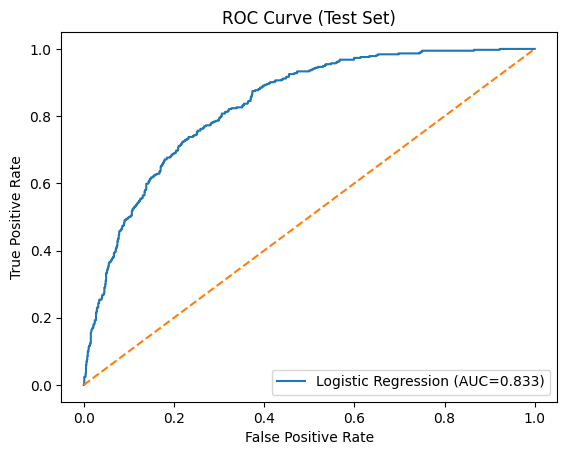

In [38]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

The final Logistic Regression model achieves a ROC-AUC of 0.833 on the test set, indicating strong ability to distinguish between churners and non-churners. The model attains a recall of 0.80 for the churn class, successfully identifying the majority of at-risk customers, which is critical for churn prediction tasks.

This high recall is achieved at the cost of lower precision (0.49), meaning that a portion of non-churning customers are incorrectly flagged as churners. However, in a churn prediction context, this trade-off is acceptable, as failing to identify a churner is typically more costly than targeting a non-churner.

The model correctly identifies 298 churners while missing 76, demonstrating strong sensitivity to the minority class. Although 313 non-churners are incorrectly classified as churners, this aligns with the model’s objective of prioritizing recall.

Overall, the model provides a strong balance between discrimination (ROC-AUC) and recall, making it suitable for deployment in customer retention strategies where maximizing churn detection is the primary objective.